# Relevância de Features vs Clusters Ontológicos (UMAP)

Este notebook calcula a importância individual de cada gene utilizando um **Random Forest Padrão (Scikit-Learn)** e projeta esses valores sobre as coordenadas **UMAP**.

O tamanho de cada ponto representa a **importância da feature**, enquanto a **cor representa os clusters** obtidos via HDBSCAN no pipeline de ontologias.

O script analisa **todos os datasets disponíveis** sequencialmente num loop.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
from sklearn.ensemble import RandomForestClassifier

## 1. Configuração Global

In [52]:
DATASETS = ["BLCA", "BRCA", "LIHC", "PRAD"]

RF_PARAMS = dict(
    n_estimators=100000,
    random_state=42,
    n_jobs=-1
)

print(f"Datasets que serão processados: {DATASETS}")

Datasets que serão processados: ['BLCA', 'BRCA', 'LIHC', 'PRAD']


## 2. Processamento e Geração de Gráficos (Por Dataset)
Para cada tipo de câncer:
1. Treina o Random Forest
2. Cruza as importâncias com as coordenadas UMAP e Clusters HDBSCAN
3. Gera Gráfico Scatter (UMAP)
4. Gera Gráfico de Barras com a relevância média por cluster

Carregado: 426 amostras, 20530 features para BLCA.
Treinando Random Forest...


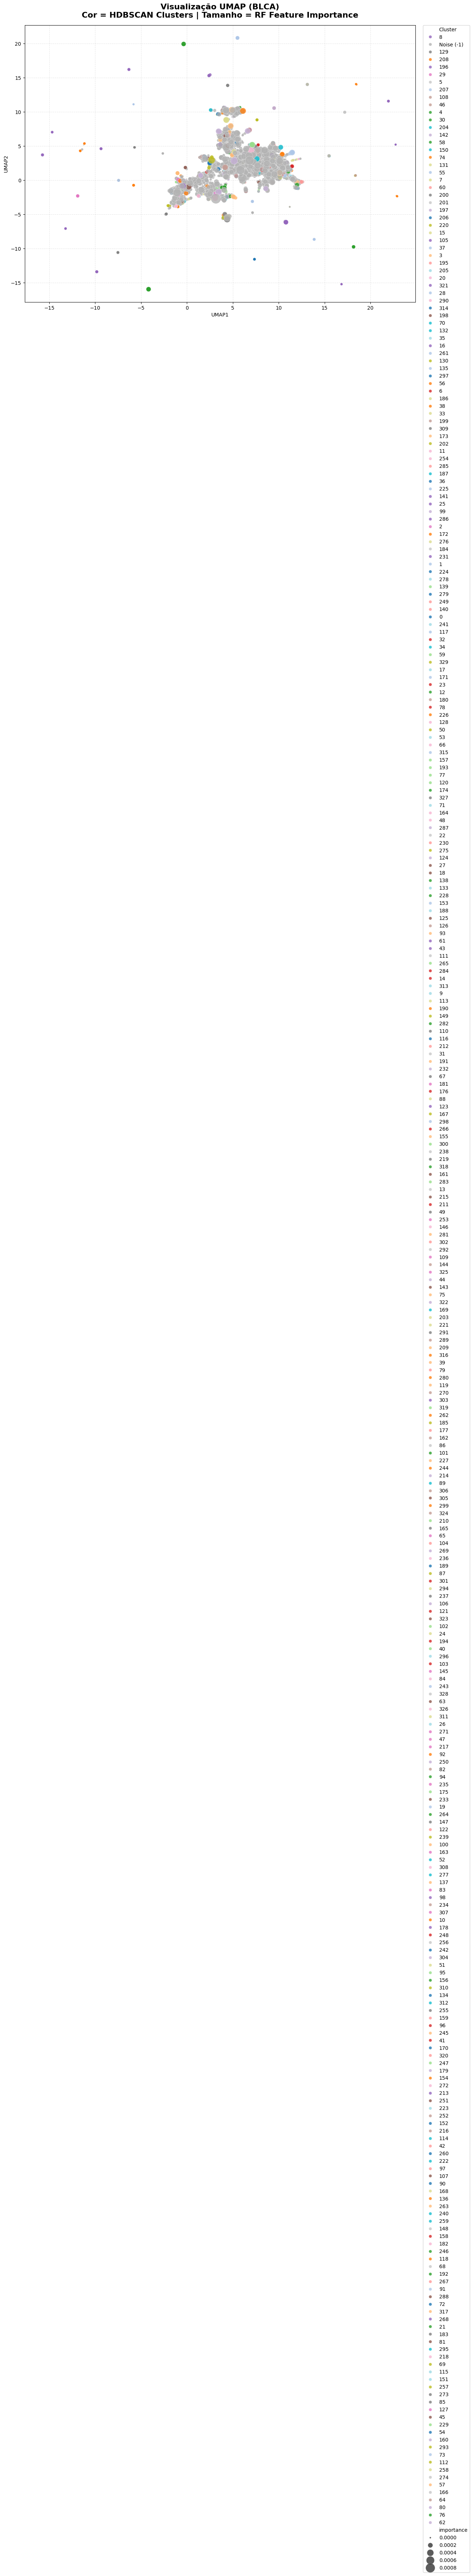


==================== Ranking de Importância por Cluster (BLCA) ====================


,Tamanho,Importancia_Media,Importancia_Soma
Cluster,,,
239,8,1.188347e-04,0.000951
62,5,1.187077e-04,0.000594
247,7,1.076753e-04,0.000754
169,8,9.557354e-05,0.000765
137,6,9.555350e-05,0.000573
...,...,...,...
204,11,4.397950e-06,0.000048
131,5,4.275220e-06,0.000021
201,8,3.524150e-06,0.000028


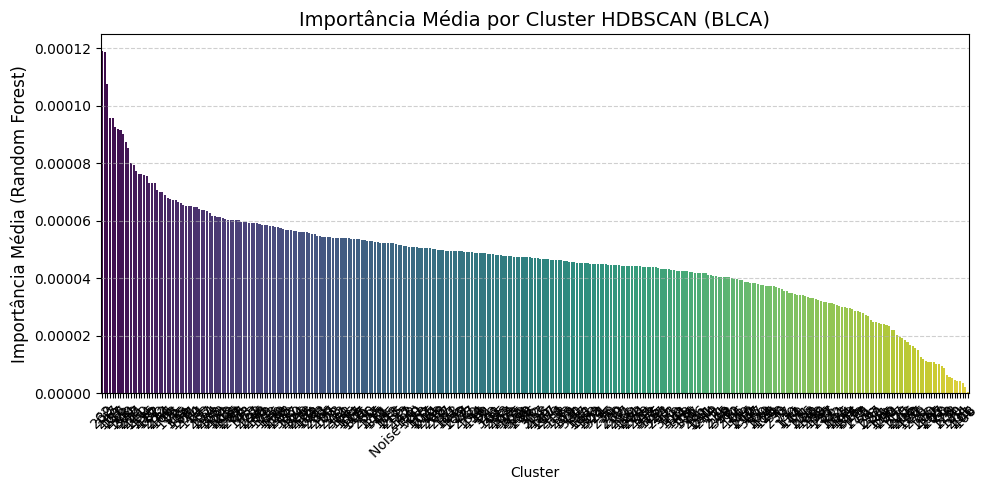

Carregado: 1215 amostras, 20530 features para BRCA.
Treinando Random Forest...


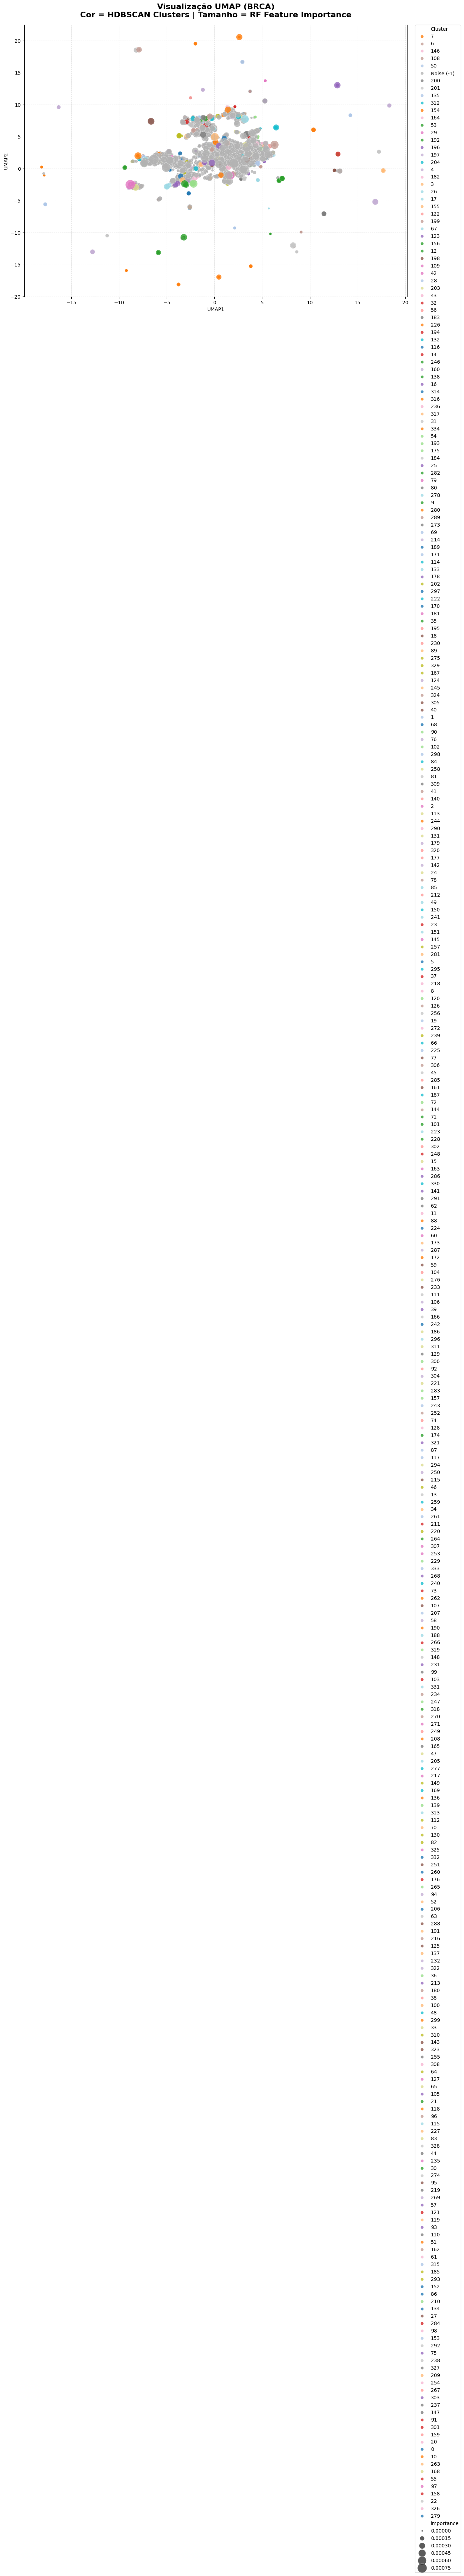


==================== Ranking de Importância por Cluster (BRCA) ====================


,Tamanho,Importancia_Media,Importancia_Soma
Cluster,,,
163,8,0.000169,0.001356
253,5,0.000134,0.000669
331,5,0.000115,0.000576
168,6,0.000112,0.000670
245,8,0.000105,0.000843
...,...,...,...
164,7,0.000007,0.000047
53,15,0.000006,0.000091
154,5,0.000006,0.000028


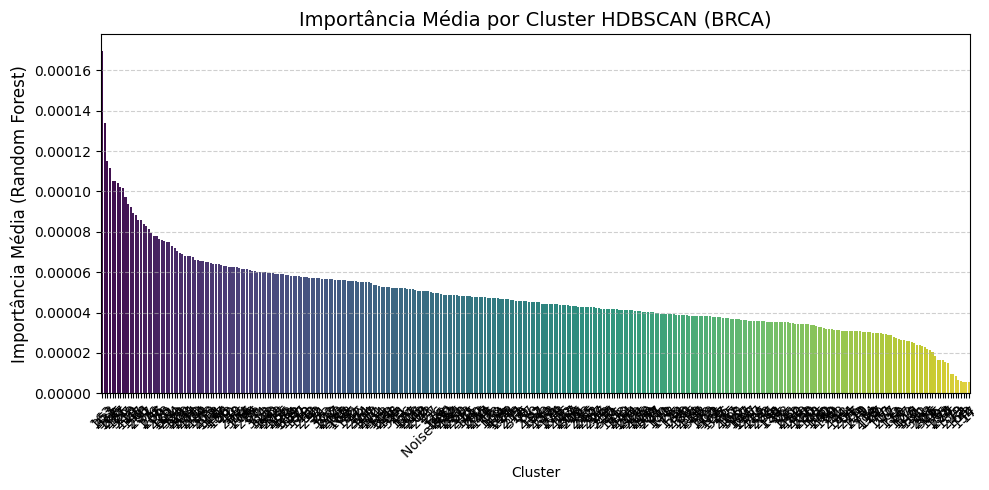

Carregado: 423 amostras, 20530 features para LIHC.
Treinando Random Forest...


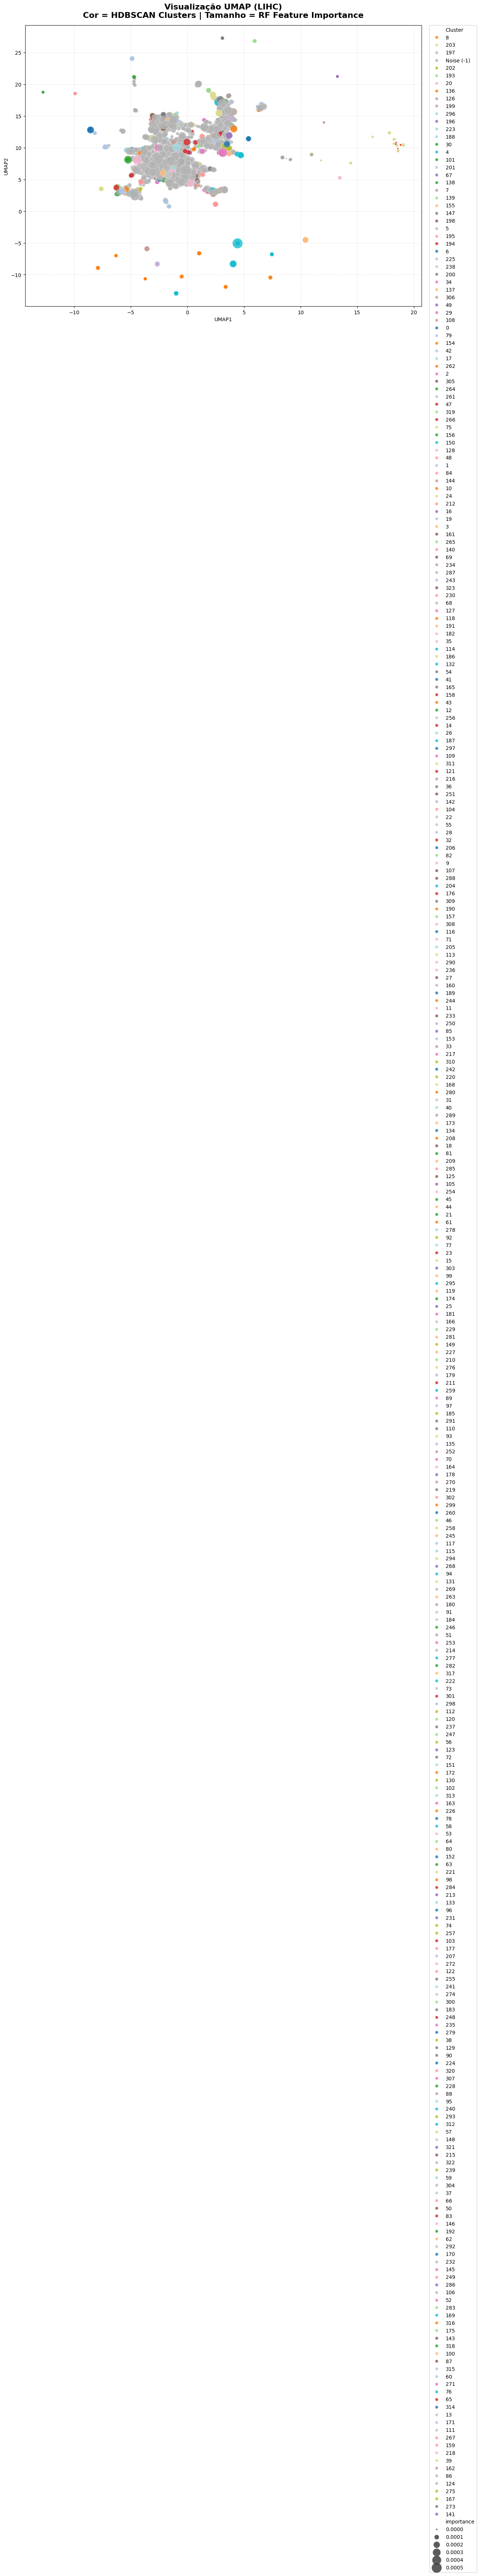


==================== Ranking de Importância por Cluster (LIHC) ====================


,Tamanho,Importancia_Media,Importancia_Soma
Cluster,,,
236,10,0.000134,0.001336
95,7,0.000098,0.000684
148,8,0.000086,0.000687
276,6,0.000084,0.000504
284,7,0.000083,0.000581
...,...,...,...
154,7,0.000004,0.000025
29,6,0.000003,0.000018
194,8,0.000003,0.000021


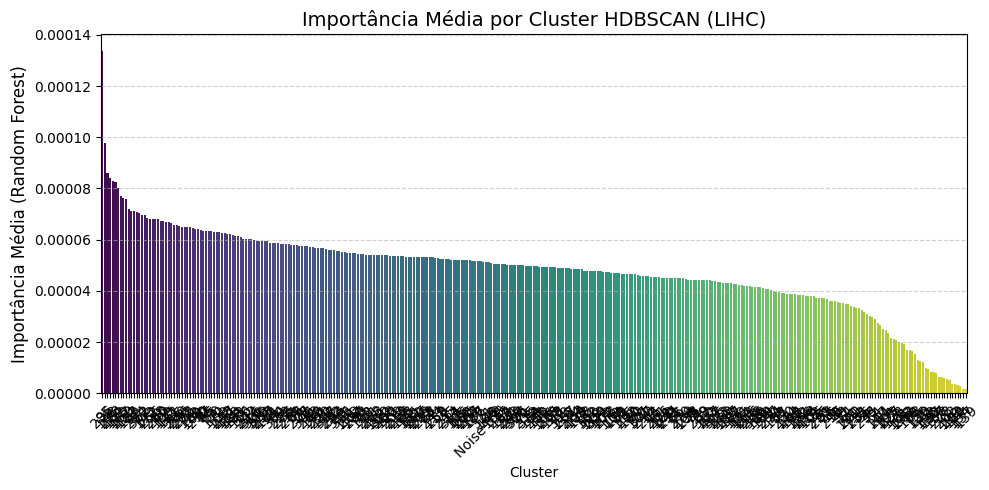

Carregado: 550 amostras, 20530 features para PRAD.
Treinando Random Forest...


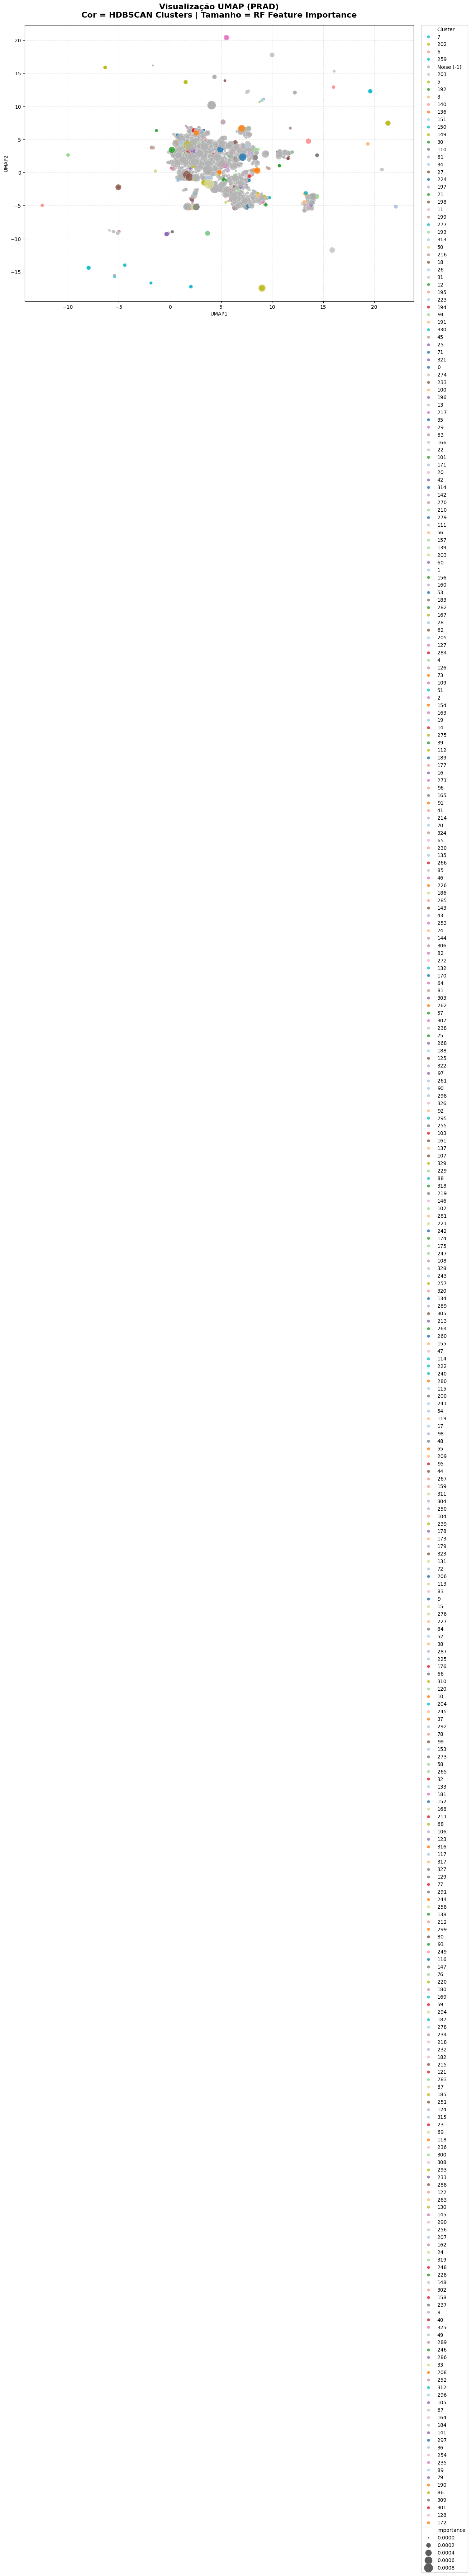


==================== Ranking de Importância por Cluster (PRAD) ====================


,Tamanho,Importancia_Media,Importancia_Soma
Cluster,,,
251,12,2.573375e-04,0.003088
168,10,1.639759e-04,0.001640
185,11,1.501622e-04,0.001652
41,12,1.329817e-04,0.001596
53,6,1.296166e-04,0.000778
...,...,...,...
27,7,1.045691e-05,0.000073
21,12,9.398664e-06,0.000113
61,15,5.124858e-06,0.000077


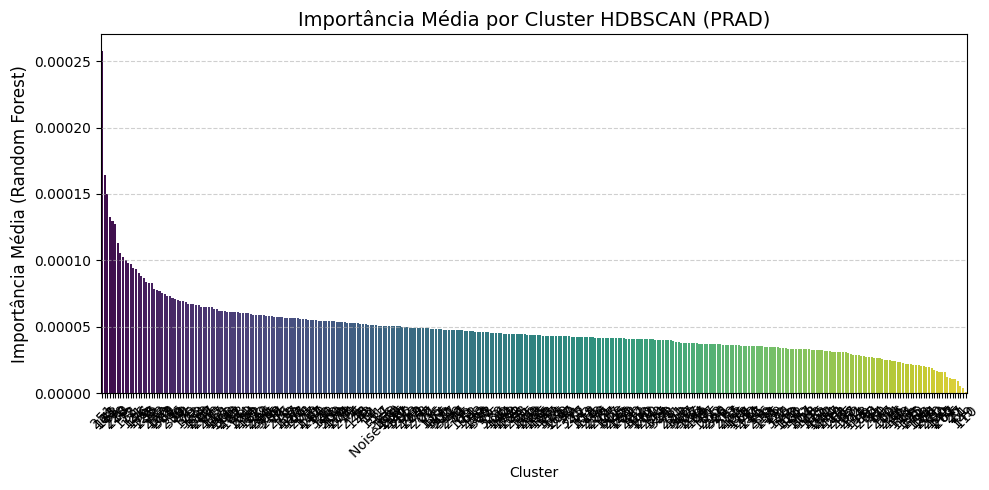

In [53]:
for DATASET in DATASETS:
    display(HTML(f"<hr><h2>➡️ Analisando Dataset: {DATASET}</h2>"))
    
    # ── 2.1 Carrega os Dados de Expressão Gênica ───────────────────────────────
    mRNA_data = pd.read_csv(f'data/input/tcga_full/{DATASET}_data/mRNA_data.csv')
    response_data = pd.read_csv(f'data/input/tcga_full/{DATASET}_data/response.csv')

    df_merged = pd.merge(mRNA_data, response_data.drop_duplicates(subset='Case_ID', keep='first'), on='Case_ID')
    X = df_merged.drop(columns=['Case_ID', 'response'])
    y = df_merged['response'].values
    feature_names = list(X.columns)

    print(f"Carregado: {X.shape[0]} amostras, {X.shape[1]} features para {DATASET}.")

    # ── 2.2 Treinamento do Random Forest ───────────────────────────────────────
    print("Treinando Random Forest...")
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X, y)

    df_importances = pd.DataFrame({
        'gene': feature_names,
        'importance': clf.feature_importances_
    })

    # ── 2.3 Merge UMAP e HDBSCAN ───────────────────────────────────────────────
    umap_path = f'data/output/umap/{DATASET}_umap_mowl.csv'
    df_umap = pd.read_csv(umap_path, index_col=0)

    cluster_path = f'data/output/clusters/genes_clustered_{DATASET}.csv'
    df_clusters = pd.read_csv(cluster_path)[['gene', 'cluster_hdbscan']]

    df_plot = df_importances.merge(df_umap, left_on='gene', right_index=True, how='inner')
    df_plot = df_plot.merge(df_clusters, on='gene', how='inner')

    # Categoriza ruído (-1)
    df_plot['Cluster'] = df_plot['cluster_hdbscan'].astype(str)
    df_plot.loc[df_plot['cluster_hdbscan'] == -1, 'Cluster'] = 'Noise (-1)'
    
    # Garante a ordem de plotagem de trás pra frente por importância
    df_plot = df_plot.sort_values(by='importance')

    # ── 2.4 Plot: Espaço Semântico (Scatter) ───────────────────────────────────
    plt.figure(figsize=(14, 10))
    unique_clusters = sorted(df_plot['Cluster'].unique())
    palette = sns.color_palette("tab20", n_colors=len(unique_clusters))
    
    color_dict = {str(c): color for c, color in zip(unique_clusters, palette)}
    if 'Noise (-1)' in color_dict:
        color_dict['Noise (-1)'] = (0.7, 0.7, 0.7, 0.5)

    sns.scatterplot(
        data=df_plot, x='UMAP1', y='UMAP2', hue='Cluster', size='importance',
        sizes=(10, 400), palette=color_dict, alpha=0.8, edgecolor="w", linewidth=0.3
    )
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, 
               frameon=True, fontsize=10, title_fontsize=12)
    plt.title(f"Visualização UMAP ({DATASET})\nCor = HDBSCAN Clusters | Tamanho = RF Feature Importance", 
              fontsize=16, fontweight='bold', pad=15)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    
    plot_path = f'data/output/umap/{DATASET}_clusters_importance_umap.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    # ── 2.5 Relatório e Plot: Relevância Média por Cluster ─────────────────────
    cluster_stats = df_plot.groupby("Cluster").agg(
        Tamanho=("gene", "count"),
        Importancia_Media=("importance", "mean"),
        Importancia_Soma=("importance", "sum")
    ).sort_values(by="Importancia_Media", ascending=False)
    
    print(f"\n{'='*20} Ranking de Importância por Cluster ({DATASET}) {'='*20}")
    display(cluster_stats)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=cluster_stats.reset_index(),
        x="Cluster", y="Importancia_Media", palette="viridis"
    )
    plt.title(f"Importância Média por Cluster HDBSCAN ({DATASET})", fontsize=14)
    plt.ylabel("Importância Média (Random Forest)", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    
    bar_path = f'data/output/umap/{DATASET}_clusters_importance_bar.png'
    plt.savefig(bar_path, dpi=300, bbox_inches='tight')
    plt.show()
    print("\n\n")

## 3. Sanity Check (Embaralhamento de Clusters do PRAD)
Para verificar se a alta relevância de certos clusters em PRAD tem de fato significado estrutural, nós embaralhamos aleatoriamente a atribuição dos genes aos clusters (mantendo o exato tamanho de cada cluster) e recalculamos as médias.
Se a distribuição da importância média desabar e os clusters ficarem todos com valores parecidos e baixos, confirmamos que os clusters reais do HDBSCAN estavam capturando informações biológicas/semânticas verdadeiras!

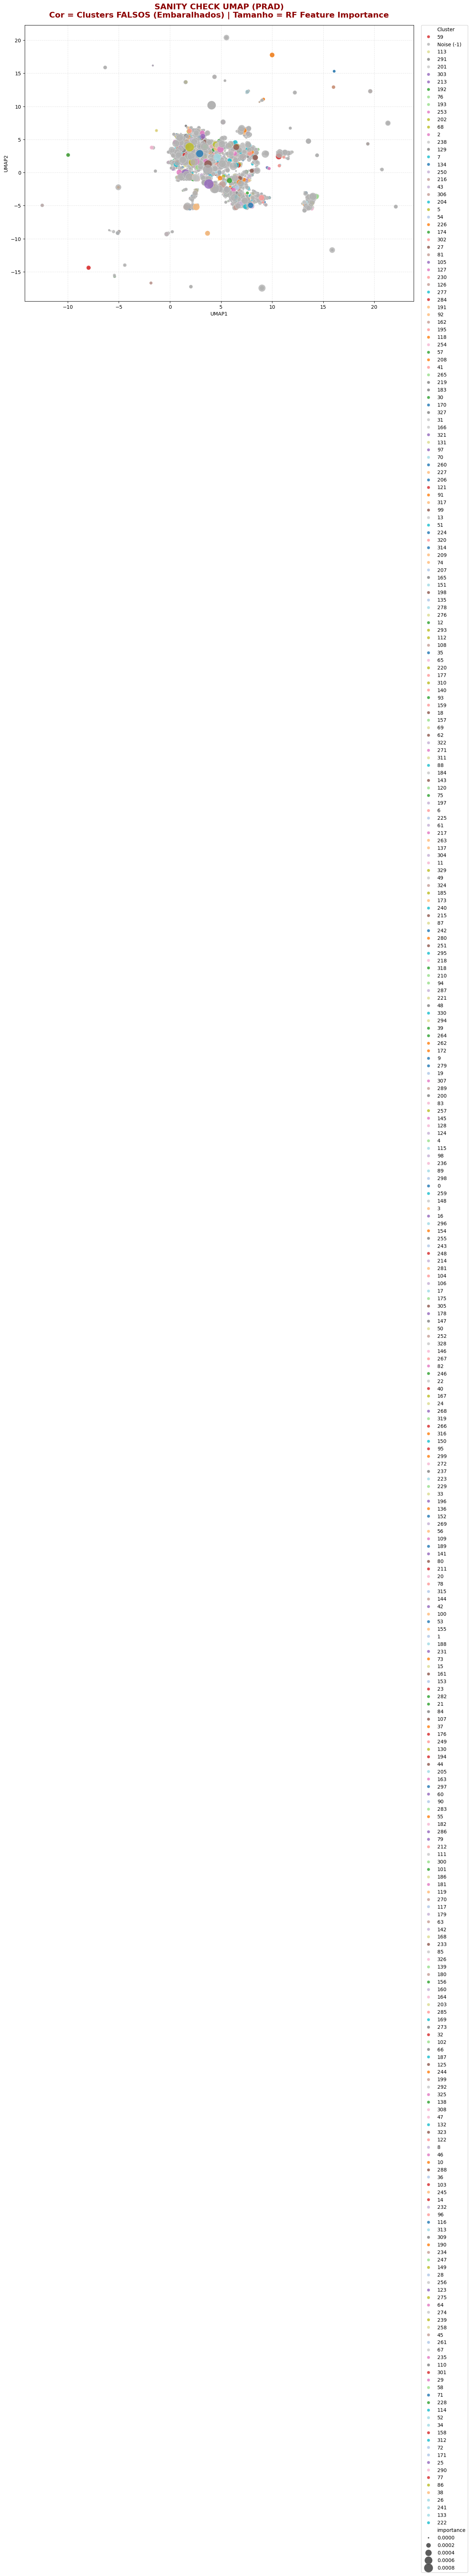


==================== Ranking de Importância por Cluster FALSO/SHUFFLED (PRAD) ====================


,Tamanho,Importancia_Media,Importancia_Soma
Cluster,,,
178,5,0.000212,0.001058
45,6,0.000122,0.000734
176,6,0.000115,0.000690
32,6,0.000115,0.000690
18,11,0.000105,0.001160
...,...,...,...
254,6,0.000025,0.000153
121,5,0.000025,0.000126
255,9,0.000023,0.000208


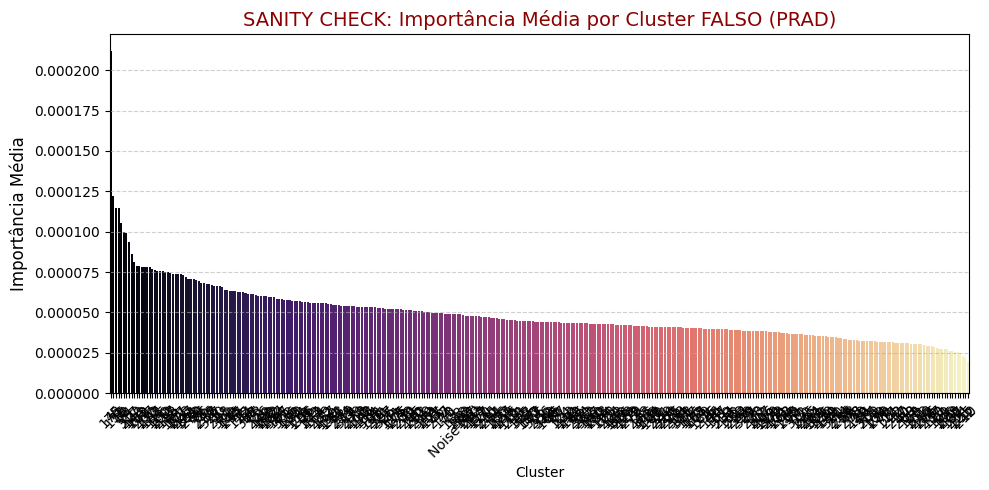

In [54]:
DATASET = "PRAD"
display(HTML(f"<hr><h2>🕹️ Sanity Check: Clusters Aleatórios ({DATASET})</h2>"))

# Recarrega os dados do PRAD
mRNA_data = pd.read_csv(f"data/input/tcga_full/{DATASET}_data/mRNA_data.csv")
response_data = pd.read_csv(f"data/input/tcga_full/{DATASET}_data/response.csv")
df_merged = pd.merge(mRNA_data, response_data.drop_duplicates(subset='Case_ID', keep='first'), on='Case_ID')
X = df_merged.drop(columns=['Case_ID', 'response'])
y = df_merged['response'].values
feature_names = list(X.columns)

# Treina RF padrão (podemos até reusar o antigo, mas por garantia treinamos rápido de novo)
clf_sanity = RandomForestClassifier(**RF_PARAMS)
clf_sanity.fit(X, y)

df_importances_sanity = pd.DataFrame({
    "gene": feature_names,
    "importance": clf_sanity.feature_importances_
})

umap_path = f"data/output/umap/{DATASET}_umap_mowl.csv"
df_umap_sanity = pd.read_csv(umap_path, index_col=0)

cluster_path = f"data/output/clusters/genes_clustered_{DATASET}.csv"
df_clusters_sanity = pd.read_csv(cluster_path)[["gene", "cluster_hdbscan"]]

# ── O EMBARALHAMENTO (SHUFFLE) ──
# Pegamos a coluna original de clusters e fazemos um shuffle nela isoladamente
# Isso preserva a quantidade exata de itens em cada cluster, apenas troca quem pertence a quem
shuffled_clusters = df_clusters_sanity["cluster_hdbscan"].values.copy()
np.random.seed(42)
np.random.shuffle(shuffled_clusters)
df_clusters_sanity["cluster_hdbscan"] = shuffled_clusters

# Merge
df_plot_sanity = df_importances_sanity.merge(df_umap_sanity, left_on="gene", right_index=True, how="inner")
df_plot_sanity = df_plot_sanity.merge(df_clusters_sanity, on="gene", how="inner")

df_plot_sanity["Cluster"] = df_plot_sanity["cluster_hdbscan"].astype(str)
df_plot_sanity.loc[df_plot_sanity["cluster_hdbscan"] == -1, "Cluster"] = "Noise (-1)"
df_plot_sanity = df_plot_sanity.sort_values(by="importance")

# ── 1. Scatter Plot (Cores agora são puramente aleatórias) ──
plt.figure(figsize=(14, 10))
unique_clusters = sorted(df_plot_sanity["Cluster"].unique())
palette = sns.color_palette("tab20", n_colors=len(unique_clusters))

color_dict = {str(c): color for c, color in zip(unique_clusters, palette)}
if "Noise (-1)" in color_dict:
    color_dict["Noise (-1)"] = (0.7, 0.7, 0.7, 0.5)

sns.scatterplot(
    data=df_plot_sanity, x="UMAP1", y="UMAP2", hue="Cluster", size="importance",
    sizes=(10, 400), palette=color_dict, alpha=0.8, edgecolor="w", linewidth=0.3
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, 
           frameon=True, fontsize=10, title_fontsize=12)
plt.title(f"SANITY CHECK UMAP ({DATASET})\nCor = Clusters FALSOS (Embaralhados) | Tamanho = RF Feature Importance", 
          fontsize=16, fontweight="bold", pad=15, color="darkred")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Relevância Média Falsa ──
cluster_stats_sanity = df_plot_sanity.groupby("Cluster").agg(
    Tamanho=("gene", "count"),
    Importancia_Media=("importance", "mean"),
    Importancia_Soma=("importance", "sum")
).sort_values(by="Importancia_Media", ascending=False)

print(f"\n{'='*20} Ranking de Importância por Cluster FALSO/SHUFFLED ({DATASET}) {'='*20}")
display(cluster_stats_sanity)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=cluster_stats_sanity.reset_index(),
    x="Cluster", y="Importancia_Media", palette="magma"
)
plt.title(f"SANITY CHECK: Importância Média por Cluster FALSO ({DATASET})", fontsize=14, color="darkred")
plt.ylabel("Importância Média", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
